Dans ce notebook, nous utilisons l’architecture **EfficientNet-B3** pour la classification des taxons de plantes par apprentissage par transfert (*transfer learning*). EfficientNet est une famille de réseaux convolutionnels conçue pour optimiser le compromis entre précision et coût de calcul grâce à une méthode appelée **compound scaling**, qui ajuste simultanément la profondeur du réseau, sa largeur et la résolution des images d’entrée. Cette approche permet d’obtenir de bonnes performances tout en limitant le nombre de paramètres nécessaires. L’architecture EfficientNet repose également sur des blocs convolutionnels efficaces utilisant notamment des convolutions séparables en profondeur (*depthwise separable convolutions*) et des mécanismes d’attention de type **Squeeze-and-Excitation**, qui permettent au réseau de mieux sélectionner les caractéristiques importantes. Dans le cadre de cette étude, les poids pré-entraînés sur ImageNet sont utilisés afin de bénéficier de représentations visuelles générales, puis la couche finale de classification est remplacée pour correspondre au nombre de taxons étudiés. Une phase de *fine-tuning* est ensuite appliquée afin d’adapter les dernières couches du réseau aux caractéristiques morphologiques spécifiques des plantes.


# Chargement du modèle sauvegardé

Si l'entraînement du modèle a déjà été réalisé et que les poids ont été sauvegardés sur Google Drive, il est possible de recharger directement le modèle afin d'éviter de relancer l'entraînement. Le modèle ainsi chargé permet ensuite de reproduire les évaluations, générer les prédictions et visualiser les résultats (classification report, matrice de confusion, erreurs de classification et Grad-CAM).

In [ ]:
# # ============================================================
# # CHARGEMENT MODELE EFFICIENTNET-B3 SAUVEGARDE
# # ============================================================

# import torch
# import torch.nn as nn
# import pickle
# import os

# from torchvision import models


# MODEL_DIR = "/content/drive/MyDrive/Projet_Plantes/Modèles CNN/EfficientNet_B3"



# # Chargement du LabelEncoder

# with open(
#     os.path.join(
#         MODEL_DIR,
#         "efficientnet_b3_label_encoder.pkl"
#     ),
#     "rb"
# ) as f:

#     encoder = pickle.load(f)



# # Nombre de classes

# num_classes = len(
#     encoder.classes_
# )

# print(
#     "Nombre de classes :",
#     num_classes
# )



# # Reconstruction EfficientNet-B3

# model = models.efficientnet_b3(
#     weights=None
# )



# # Remplacement du classifieur

# num_features = model.classifier[1].in_features


# model.classifier[1] = nn.Linear(
#     num_features,
#     num_classes
# )



# # Chargement des poids

# model.load_state_dict(
#     torch.load(
#         os.path.join(
#             MODEL_DIR,
#             "efficientnet_b3_taxons_finetuned.pth"
#         ),
#         map_location=device
#     )
# )



# # Passage sur GPU/CPU

# model = model.to(device)


# # Mode évaluation

# model.eval()


# print("✅ EfficientNet-B3 chargé avec succès")

# Importation des données

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import EfficientNet_B3_Weights

from PIL import Image

from tqdm.notebook import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from google.colab import drive



# Seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


# Drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 2. ACCES DATASET
# ============================================================

BASE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Projet_Plantes"
)


print(
    "Projet accessible :",
    BASE_PROJECT_DIR.exists()
)


path = "/content/drive/MyDrive/Projet_Plantes"

# création du chemin (variable path) vers le dossier Projet_Plantes
os.listdir('/content/drive/MyDrive')
os.path.exists('/content/drive/MyDrive/Projet_Plantes')
path = "/content/drive/MyDrive/Projet_Plantes"


# décompression de taxons
if not os.path.exists('/content/TAXONS/all'):
    print("Décompression de TAXONS en cours... (quelques minutes)")
    with zipfile.ZipFile(path + "/TAXONS.zip", 'r') as z:
        z.extractall('/content/TAXONS')
    print("TAXONS décompressé ✓")
else:
    print("TAXONS déjà décompressé ✓")
path_bdd = '/content/TAXONS/all/'


Projet accessible : True
Décompression de TAXONS en cours... (quelques minutes)
TAXONS décompressé ✓


## Chargement des splits

In [ ]:
# ============================================================
# 3. CHARGEMENT DES SPLITS
# ============================================================


SPLIT_DIR = BASE_PROJECT_DIR / "V2_TAXONS_CLEAN_SPLITS"
df_train = pd.read_csv(
    SPLIT_DIR / "train.csv")
df_val = pd.read_csv(
    SPLIT_DIR / "val.csv")
df_test = pd.read_csv(
    SPLIT_DIR / "test.csv")



print("="*50)

print(
    f"Train : {len(df_train):,}")

print(
    f"Val   : {len(df_val):,}")

print(
    f"Test  : {len(df_test):,}")

print(df_train.columns)
display(df_train.head())

Train : 67,377
Val   : 14,370
Test  : 14,418
Index(['chemin', 'taxon_label', 'source_dataset', 'group_id'], dtype='object')


,chemin,taxon_label,source_dataset,group_id
0,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,0
1,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,1
2,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,2
3,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,3
4,/kaggle/input/datasets/bronislawpodhajski/plan...,apple,New Plant Diseases,4


In [ ]:
# ============================================================
# 4. CORRECTION CHEMINS
# ============================================================

def corriger_chemin(chemin):

    nom_image = os.path.basename(chemin)

    classe = os.path.basename(
        os.path.dirname(chemin))

    return (
        f"/content/TAXONS/all/"
        f"{classe}/{nom_image}")

for df in [
    df_train,
    df_val,
    df_test]:

    df["chemin"] = df["chemin"].apply(
        corriger_chemin)

print(
    df_train["chemin"].iloc[0])
print(
    os.path.exists(
        df_train["chemin"].iloc[0]))

/content/TAXONS/all/apple/npd_apple_009115.jpg
True


## encodage + classe weight

In [ ]:
# ============================================================
# 5. LABEL ENCODING
# ============================================================
encoder = LabelEncoder()

df_train["label_idx"] = encoder.fit_transform(
    df_train["taxon_label"])
df_val["label_idx"] = encoder.transform(
    df_val["taxon_label"])
df_test["label_idx"] = encoder.transform(
    df_test["taxon_label"])
num_classes = len(
    encoder.classes_)
print(
    "Nombre de classes :",
    num_classes)

Nombre de classes : 14


In [ ]:
classes = np.unique(
    df_train["label_idx"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_train["label_idx"])
print(class_weights)
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu")

print(device)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

[0.70237053 3.0421257  1.55950838 0.75587292 0.75056813 1.24679867
 1.57946927 1.40556158 0.98397932 3.13323103 1.34468926 3.17038396
 1.53220085 0.26615656]
cuda


In [ ]:
# ============================================================
# 6. DATASET
# ============================================================


class PlantDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["chemin"]
        label = self.df.iloc[idx]["label_idx"]
        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(
                image)
        return image, label

# EfficientNet_B3_Weights

## Préparation du modèle

In [ ]:
# ============================================================
# 7. TRANSFORMATIONS DENSENET
# ============================================================


weights = EfficientNet_B3_Weights.DEFAULT
transform_train = transforms.Compose([
    transforms.Resize(320),
    transforms.RandomHorizontalFlip(
        p=0.5),
    transforms.RandomRotation(
        20),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406],
        std=[
            0.229,
            0.224,
            0.225])])

transform_test = transforms.Compose([

    transforms.Resize(320),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406],
        std=[
            0.229,
            0.224,
            0.225])])

In [ ]:
# ============================================================
# 8. DATALOADERS
# ============================================================


dataset_train = PlantDataset(
    df_train,
    transform_train)
dataset_val = PlantDataset(
    df_val,
    transform_test)
dataset_test = PlantDataset(
    df_test,
    transform_test)

BATCH_SIZE = 32
dataloader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True)
dataloader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False)
dataloader_test = DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False)

In [ ]:
# ============================================================
# 9. MODELE EFFICIENT NET B3
# ============================================================


model = models.efficientnet_b3(
    weights=weights)

# Gel des poids convolutionnels

for param in model.parameters():

    param.requires_grad = False


# Remplacement du classifieur
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(
    num_features,
    num_classes)

model = model.to(device)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 227MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=14, bias=True)
)


In [ ]:
X_batch, y_batch = next(
    iter(dataloader_train))
print(
    X_batch.shape)
print(
    y_batch.shape)

torch.Size([32, 3, 300, 300])
torch.Size([32])


In [ ]:
# ============================================================
# 11. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3)

## Entrainement du modèle
Pendant cette première phase :

*  le backbone efficientnet est gelé
*  seul le classifieur final apprend les classes de taxons


In [ ]:
# ============================================================
# 12. EVALUATION
# ============================================================


def evaluate(loader):

    model.eval()


    predictions = []

    true_labels = []

    with torch.no_grad():


        for X, y in loader:

            X = X.to(device)

            outputs = model(
                X
            )
            pred = torch.argmax(
                outputs,
                dim=1
            )
            predictions.extend(
                pred.cpu().numpy() )
            true_labels.extend(
                y.numpy())



    predictions = np.array(
        predictions)
    true_labels = np.array(
        true_labels)
    accuracy = accuracy_score(
        true_labels,
        predictions)

    f1 = f1_score(
        true_labels,
        predictions,
        average="macro")
    return {
        "accuracy": accuracy,

        "f1": f1
    }

In [ ]:
# ============================================================
# 13. ENTRAINEMENT INITIAL OPTIMISE
# ============================================================

# Historique apprentissage initial

history = {

    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}


epochs = 10


for epoch in range(epochs):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    loss_total = 0

    correct_train = 0
    total_train = 0


    progress_bar = tqdm(
        dataloader_train,
        desc=f"Epoch {epoch+1}/{epochs}"
    )


    for X_batch, y_batch in progress_bar:


        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        optimizer.zero_grad()


        predictions = model(
            X_batch
        )


        loss = criterion(
            predictions,
            y_batch
        )


        loss.backward()

        optimizer.step()


        loss_total += loss.item()



        # Accuracy train

        predicted_classes = torch.argmax(
            predictions,
            dim=1
        )


        correct_train += (
            predicted_classes == y_batch
        ).sum().item()


        total_train += y_batch.size(0)



        progress_bar.set_postfix(
            loss=loss.item()
        )



    train_loss = (
        loss_total /
        len(dataloader_train))


    train_accuracy = (
        correct_train /
        total_train
    )



    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss = 0

    correct_val = 0
    total_val = 0


    with torch.no_grad():


        for X_val, y_val in dataloader_val:


            X_val = X_val.to(device)
            y_val = y_val.to(device)


            pred = model(
                X_val)


            loss = criterion(
                pred,
                y_val)


            val_loss += loss.item()



            # Accuracy validation

            predicted_classes = torch.argmax(
                pred,
                dim=1)


            correct_val += (
                predicted_classes == y_val
            ).sum().item()


            total_val += y_val.size(0)



    val_loss = (
        val_loss /
        len(dataloader_val))


    val_accuracy = (
        correct_val /
        total_val)



    # ========================================================
    # Sauvegarde historique
    # ========================================================

    history["train_loss"].append(
        train_loss)

    history["val_loss"].append(
        val_loss)

    history["train_accuracy"].append(
        train_accuracy)

    history["val_accuracy"].append(
        val_accuracy)



    # Scheduler

    scheduler.step(
        val_loss)



    print(
        f"""
Epoch {epoch+1}/{epochs}

Train loss :
{train_loss:.4f}

Val loss :
{val_loss:.4f}


Train accuracy :
{train_accuracy:.4f}


Val accuracy :
{val_accuracy:.4f}

"""
    )

Epoch 1/10:   0%|          | 0/2106 [00:00<?, ?it/s]


Epoch 1/10

Train loss :
0.1562

Val loss :
0.1043


Train accuracy :
0.9402


Val accuracy :
0.9700




Epoch 2/10:   0%|          | 0/2106 [00:00<?, ?it/s]


Epoch 2/10

Train loss :
0.1387

Val loss :
0.0942


Train accuracy :
0.9437


Val accuracy :
0.9717




Epoch 3/10:   0%|          | 0/2106 [00:00<?, ?it/s]

...


Epoch 8/10

Train loss :
0.1124

Val loss :
0.0675


Train accuracy :
0.9495


Val accuracy :
0.9768




Epoch 9/10:   0%|          | 0/2106 [00:00<?, ?it/s]


Epoch 9/10

Train loss :
0.1128

Val loss :
0.0700


Train accuracy :
0.9496


Val accuracy :
0.9760




Epoch 10/10:   0%|          | 0/2106 [00:00<?, ?it/s]


Epoch 10/10

Train loss :
0.1097

Val loss :
0.0715


Train accuracy :
0.9506


Val accuracy :
0.9779




In [ ]:
metrics_train = evaluate(
    dataloader_train)
metrics_val = evaluate(
    dataloader_val)
metrics_test = evaluate(
    dataloader_test)



print("===== TRAIN =====")
print(
    "Accuracy :",
    metrics_train["accuracy"])
print(
    "F1 :",
    metrics_train["f1"])

print("\n===== VALIDATION =====")
print(
    "Accuracy :",
    metrics_val["accuracy"])
print(
    "F1 :",
    metrics_val["f1"])

print("\n===== TEST =====")
print(
    "Accuracy :",
    metrics_test["accuracy"])
print(
    "F1 :",
    metrics_test["f1"])

## Fine tuning

In [ ]:
# ============================================================
# Fine tuning
# ============================================================


# Historique du fine tuning

history_ft = {

    "train_loss": [],

    "val_loss": [],

    "train_accuracy": [],

    "val_accuracy": []}


In [ ]:
# ============================================================
# 15. FINE TUNING EFFICIENTNET
# ============================================================
for name, param in model.named_parameters():

    if (
        "features.6" in name
        or
        "features.7" in name
        or
        "classifier" in name
    ):
        param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(

    filter(
        lambda p: p.requires_grad,
        model.parameters()),
    lr=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.1,

    patience=3)

In [ ]:
# ============================================================
# 16. ENTRAINEMENT FINE TUNING
# ============================================================


epochs_ft = 5


for epoch in range(epochs_ft):
    model.train()
    loss_total = 0
    progress_bar = tqdm(
        dataloader_train,
        desc=f"Fine tuning Epoch {epoch+1}/{epochs_ft}" )



    for X_batch, y_batch in progress_bar:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)



        optimizer.zero_grad()
        predictions = model(
            X_batch)
        loss = criterion(
            predictions,
            y_batch)

        loss.backward()
        optimizer.step()
        loss_total += loss.item()





    # ========================================================
    # Validation
    # ========================================================


    model.eval()

    val_loss = 0

    with torch.no_grad():

        for X_val, y_val in dataloader_val:



            X_val = X_val.to(device)

            y_val = y_val.to(device)



            pred = model(
                X_val)



            loss = criterion(
                pred,
                y_val)



            val_loss += loss.item()



    train_loss = loss_total / len(
        dataloader_train)


    val_loss = val_loss / len(
        dataloader_val)



    # ========================================================
    # Accuracy train / validation
    # ========================================================


    train_metrics = evaluate(
        dataloader_train)


    val_metrics = evaluate(
        dataloader_val)



    # ========================================================
    # Sauvegarde historique
    # ========================================================


    history_ft["train_loss"].append(
        train_loss)


    history_ft["val_loss"].append(
        val_loss)


    history_ft["train_accuracy"].append(
        train_metrics["accuracy"])


    history_ft["val_accuracy"].append(
        val_metrics["accuracy"])



    scheduler.step(
        val_loss)



    print(

        f"""
Fine tuning epoch {epoch+1}/{epochs_ft}

Train loss :
{train_loss:.4f}

Val loss :
{val_loss:.4f}

Train accuracy :
{train_metrics["accuracy"]:.4f}

Val accuracy :
{val_metrics["accuracy"]:.4f}

""" )

Fine tuning Epoch 1/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 1/5

Train loss :
0.0751

Val loss :
0.0336

Train accuracy :
0.9895

Val accuracy :
0.9891




Fine tuning Epoch 2/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 2/5

Train loss :
0.0461

Val loss :
0.0279

Train accuracy :
0.9917

Val accuracy :
0.9903




Fine tuning Epoch 3/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 3/5

Train loss :
0.0314

Val loss :
0.0165

Train accuracy :
0.9955

Val accuracy :
0.9940




Fine tuning Epoch 4/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 4/5

Train loss :
0.0239

Val loss :
0.0158

Train accuracy :
0.9958

Val accuracy :
0.9951




Fine tuning Epoch 5/5:   0%|          | 0/2106 [00:00<?, ?it/s]


Fine tuning epoch 5/5

Train loss :
0.0202

Val loss :
0.0124

Train accuracy :
0.9967

Val accuracy :
0.9961




In [ ]:
# ============================================================
# 17. FUSION HISTORIQUE ENTRAINEMENT + FINE TUNING
# ============================================================


history_complete = {
    "train_loss":
    history["train_loss"] + history_ft["train_loss"],
    "val_loss":
    history["val_loss"] + history_ft["val_loss"],
   "train_accuracy":
    history["train_accuracy"] + history_ft["train_accuracy"],
    "val_accuracy":
    history["val_accuracy"] + history_ft["val_accuracy"]}


NameError: name 'history' is not defined

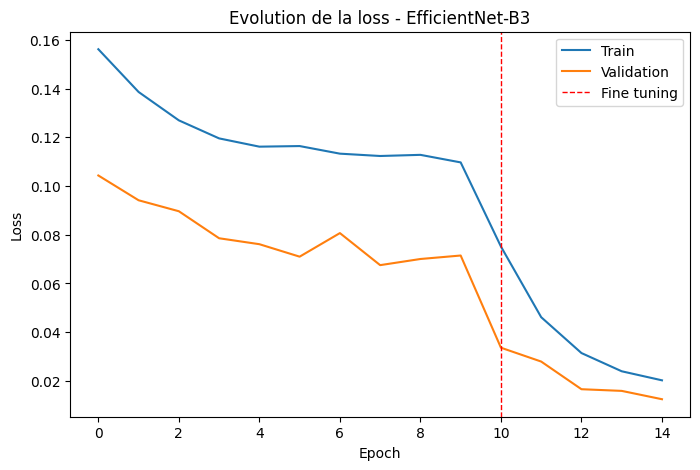

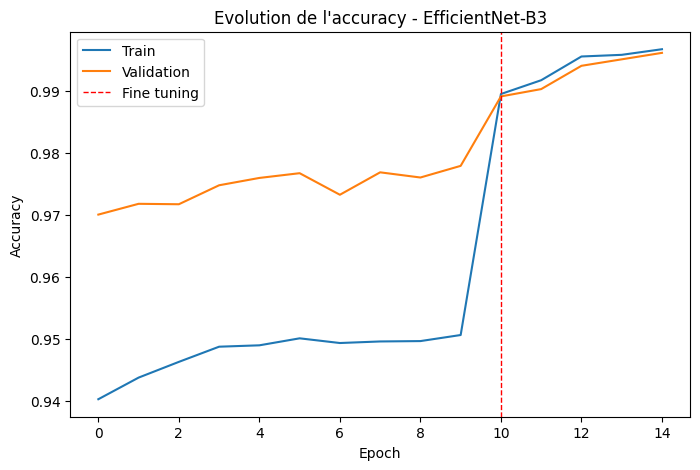

In [ ]:
# ============================================================
# COURBES APPRENTISSAGE EfficientNet-B3
# ============================================================


# Evolution Loss

plt.figure(figsize=(8,5))


plt.plot(
    history_complete["train_loss"],
    label="Train")


plt.plot(
    history_complete["val_loss"],
    label="Validation")


plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Fine tuning")


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Evolution de la loss - EfficientNet-B3")


plt.legend()

plt.show()



# ============================================================
# Evolution Accuracy
# ============================================================


plt.figure(figsize=(8,5))


plt.plot(
    history_complete["train_accuracy"],
    label="Train")


plt.plot(
    history_complete["val_accuracy"],
    label="Validation")


plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Fine tuning")


plt.xlabel("Epoch")
plt.ylabel("Accuracy")


plt.title(
    "Evolution de l'accuracy - EfficientNet-B3")


plt.legend()

plt.show()

In [ ]:
# ============================================================
# SAUVEGARDE MODELE EFFICIENTNET-B3
# ============================================================

import os
import pickle
import json
import torch


MODEL_DIR = "/content/drive/MyDrive/Projet_Plantes/Modèles CNN/EfficientNet_B3"


# Création du dossier

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)



# Sauvegarde des poids

torch.save(
    model.state_dict(),
    os.path.join(
        MODEL_DIR,
        "efficientnet_b3_taxons_finetuned.pth"
    )
)



# Sauvegarde du LabelEncoder

with open(
    os.path.join(
        MODEL_DIR,
        "efficientnet_b3_label_encoder.pkl"
    ),
    "wb"
) as f:

    pickle.dump(
        encoder,
        f
    )



# Sauvegarde configuration

config = {

    "model": "EfficientNet-B3",

    "num_classes": num_classes,

    "classes": list(
        encoder.classes_
    ),

    "input_size": 300,

    "normalization_mean": [
        0.485,
        0.456,
        0.406
    ],

    "normalization_std": [
        0.229,
        0.224,
        0.225
    ]
}


with open(
    os.path.join(
        MODEL_DIR,
        "efficientnet_b3_config.json"
    ),
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


print("✅ EfficientNet-B3 sauvegardé dans :")
print(MODEL_DIR)

print("\nFichiers :")
print(os.listdir(MODEL_DIR))

✅ EfficientNet-B3 sauvegardé dans :
/content/drive/MyDrive/Projet_Plantes/Modèles CNN/EfficientNet_B3

Fichiers :
['efficientnet_b3_taxons_finetuned.pth', 'efficientnet_b3_label_encoder.pkl', 'efficientnet_b3_config.json']


## Résultats

In [ ]:
metrics_train = evaluate(
    dataloader_train)
metrics_val = evaluate(
    dataloader_val)
metrics_test = evaluate(
    dataloader_test)

print("===== TRAIN =====")

print( "Accuracy :",
    metrics_train["accuracy"])
print(
    "F1 :",
    metrics_train["f1"])

print("\n===== VALIDATION =====")

print(
    "Accuracy :",
    metrics_val["accuracy"])

print(
    "F1 :",
    metrics_val["f1"])

print("\n===== TEST =====")
print(
    "Accuracy :",
    metrics_test["accuracy"])
print(
    "F1 :",
    metrics_test["f1"])

===== TRAIN =====
Accuracy : 0.9968832094038025
F1 : 0.9973770881646182

===== VALIDATION =====
Accuracy : 0.9961029923451635
F1 : 0.9966926574668632

===== TEST =====
Accuracy : 0.9961853239006797
F1 : 0.9967040776590063


In [ ]:
# ============================================================
# 18. SAUVEGARDE
# ============================================================
torch.save(
    model.state_dict(),
    "efficientnet_b3_taxons_finetuned.pth")

In [ ]:
# ============================================================
# 19. PREDICTIONS
# ============================================================


def get_predictions(loader):

    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():


        for images, labels in loader:

            images = images.to(device)

            outputs = model(
                images)

            predictions = torch.argmax(
                outputs,
                dim=1)

            y_true.extend(
                labels.numpy())

            y_pred.extend(
                predictions.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

In [ ]:
# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================


y_true, y_pred = get_predictions(
    dataloader_test)

report = classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_,
    digits=4)
print(report)

## Interprétabilité

### Matrice de confusion

In [ ]:
# ============================================================
# 21. MATRICE DE CONFUSION
# ============================================================


cm = confusion_matrix(
    y_true,
    y_pred)

class_names = encoder.classes_

plt.figure(
    figsize=(12,10))

sns.heatmap(

    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt="d")

plt.xlabel(
    "Classe prédite")


plt.ylabel(
    "Classe réelle")


plt.title(
    "Matrice de confusion - Efficient Net Taxons")


plt.xticks(
    rotation=90)


plt.yticks(
    rotation=0)


plt.show()

### Visualisation maivaises prédictions

In [ ]:
# ============================================================
# 22. ERREURS DE CLASSIFICATION
# ============================================================



erreurs = np.where(
    y_true != y_pred
)[0]

print(
    f"Nombre d'erreurs : {len(erreurs)}")

plt.figure(
    figsize=(15,15))

for i, idx in enumerate(erreurs[:9]):


    plt.subplot(
        3,
        3,
        i+1)
    img_path = df_test.iloc[idx]["chemin"]


    img = Image.open(
        img_path)

    plt.imshow(
        img)

    vrai = encoder.inverse_transform(
        [y_true[idx]])[0]

    pred = encoder.inverse_transform(
        [y_pred[idx]]
    )[0]
    plt.title(
        f"Vrai : {vrai}\nPrédit : {pred}",
        fontsize=9)
    plt.axis(
        "off")

plt.tight_layout()

plt.show()

### Grad CAM

In [ ]:

!pip install grad-cam

In [ ]:

from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.model_targets import (
    ClassifierOutputTarget)

from pytorch_grad_cam.utils.image import (
    show_cam_on_image)

In [ ]:

images, labels = next(
    iter(dataloader_test))

img = images[0].unsqueeze(0).to(
    device)

label = labels[0]

prediction = model(
    img)

classe_predite = torch.argmax(
    prediction,
    dim=1
).item()

print(
    "Classe réelle :",
    encoder.classes_[label])
print(
    "Classe prédite :",
    encoder.classes_[classe_predite])

In [ ]:

target_layers = [

    model.features[7]]

cam = GradCAM(

    model=model,

    target_layers=target_layers)
targets = [

    ClassifierOutputTarget(
        classe_predite)]
grayscale_cam = cam(
    input_tensor=img,
    targets=targets)

grayscale_cam = grayscale_cam[0]

In [ ]:


img_display = images[0].permute(
    1,
    2,
    0
).numpy()



mean = np.array(
    [0.485,
        0.456,
        0.406])

std = np.array(
    [0.229,
        0.224,
        0.225])

img_display = (
    std * img_display
    + mean)
img_display = np.clip(
    img_display,
    0,
    1)

visualization = show_cam_on_image(

    img_display,

    grayscale_cam,

    use_rgb=True)
plt.figure(
    figsize=(12,5))

plt.subplot(
    1,
    2,
    1)
plt.imshow(
    img_display)
plt.title(
    "Image originale")

plt.axis(
    "off")

plt.subplot(
    1,
    2,
    2)
plt.imshow(
    visualization)
plt.title(
    "Grad-CAM Efficient Net")
plt.axis(
    "off")
plt.show()

In [ ]:
## Pour 10 classes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# Récupération d'une image
images, labels = next(iter(dataloader_test))

img = images[0].unsqueeze(0).to(device)

label = labels[0]


# Prédiction
prediction = model(img)

classe_predite = torch.argmax(
    prediction,
    dim=1
).item()


print(
    "Classe réelle :",
    encoder.classes_[label]
)

print(
    "Classe prédite :",
    encoder.classes_[classe_predite]
)


# Couche cible EfficientNet
# Pour EfficientNet torchvision :
target_layers = [
    model.features[-1]
]


cam = GradCAM(
    model=model,
    target_layers=target_layers
)



# Dé-normalisation image
img_display = images[0].permute(1, 2, 0).numpy()


mean = np.array(
    [0.485, 0.456, 0.406]
)

std = np.array(
    [0.229, 0.224, 0.225]
)


img_display = (
    std * img_display
    + mean
)


img_display = np.clip(
    img_display,
    0,
    1
)



# Nombre de classes
num_classes = len(encoder.classes_)



plt.figure(
    figsize=(15, 12)
)



# Image originale
plt.subplot(
    3,
    4,
    1
)

plt.imshow(img_display)

plt.title(
    "Image originale\n"
    + encoder.classes_[label]
)

plt.axis("off")



# Grad-CAM des 10 classes
for class_idx in range(num_classes):

    targets = [
        ClassifierOutputTarget(class_idx)
    ]


    grayscale_cam = cam(
        input_tensor=img,
        targets=targets
    )[0]


    visualization = show_cam_on_image(
        img_display,
        grayscale_cam,
        use_rgb=True)


    plt.subplot(
        3,
        4,
        class_idx + 2)


    plt.imshow(
        visualization)


    plt.title(
        f"{class_idx} : {encoder.classes_[class_idx]}")


    plt.axis(
        "off")



plt.tight_layout()
plt.show()